In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2


from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [4]:
train_path = "C:/Users/admin/Downloads/pneumonia/archive/chest_xray/train"
val_path = "C:/Users/admin/Downloads/pneumonia/archive/chest_xray/val"
test_path = "C:/Users/admin/Downloads/pneumonia/archive/chest_xray/test"

In [5]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

val_generator = test_datagen.flow_from_directory(
    val_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [7]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [8]:
base_model.trainable = False

In [9]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)

output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input,
              outputs=output)

In [10]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [11]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 234s 1s/step - accuracy: 0.7406 - loss: 0.5806 - val_accuracy: 0.5000 - val_loss: 0.7435
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 227s 1s/step - accuracy: 0.7429 - loss: 0.5766 - val_accuracy: 0.5000 - val_loss: 0.8680
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 233s 1s/step - accuracy: 0.7429 - loss: 0.5756 - val_accuracy: 0.5000 - val_loss: 0.8505
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 304s 2s/step - accuracy: 0.7429 - loss: 0.5725 - val_accuracy: 0.5000 - val_loss: 0.8281
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 237s 1s/step - accuracy: 0.7429 - loss: 0.5741 - val_accuracy: 0.5000 - val_loss: 0.8553
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 297s 2s/step - accuracy: 0.7429 - loss: 0.5728 - val_accuracy: 0.5000 - val_loss: 0.8222
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 371s 2s/step - accuracy: 0.7429 - loss: 0.5728 - val_accuracy: 0.5000 - val_loss: 0.8550
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 396s 2s/step - accuracy: 0.7429 - loss: 0.5715 - val_accu

In [12]:
model.save(r"C:\Users\admin\Downloads\pneumonia\pneumonia_model.keras")

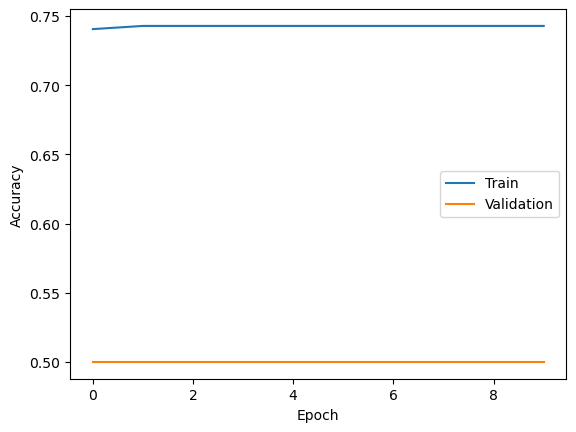

In [13]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.legend(["Train","Validation"])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

In [14]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

pred = model.predict(test_generator)
pred = (pred > 0.5).astype(int)
cm = confusion_matrix(test_generator.classes, pred)
print(cm)

print(classification_report(
    test_generator.classes,
    pred
))

20/20 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step
[[  0 234]
 [  0 390]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       234
           1       0.62      1.00      0.77       390

    accuracy                           0.62       624
   macro avg       0.31      0.50      0.38       624
weighted avg       0.39      0.62      0.48       624



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [23]:
from tensorflow.keras.preprocessing import image

img = image.load_img(
    "C:/Users/admin/Downloads/pneumonia/archive/chest_xray/test/PNEUMONIA/person96_bacteria_465.jpeg",
    target_size=(224, 224)
)

img = image.img_to_array(img)
img = img/255
img = np.expand_dims(img, axis=0)
prediction = model.predict(img)

if prediction > 0.5:
    print("PNEUMONIA")
else:
    print("NORMAL")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
PNEUMONIA


In [16]:
import cv2
import tensorflow as tf

last_conv_layer = model.get_layer("top_conv")

In [17]:
grad_model = tf.keras.models.Model(
    model.inputs,
    [
        last_conv_layer.output,
        model.output
    ]
)

In [18]:
with tf.GradientTape() as tape:

    conv_outputs, predictions = grad_model(img)

    loss = predictions[:,0]

grads = tape.gradient(loss, conv_outputs)

C:\Users\admin\AppData\Roaming\Python\Python313\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_238']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


In [19]:
pooled_grads = tf.reduce_mean(
    grads,
    axis=(0,1,2)
)

In [20]:
heatmap = tf.reduce_mean(
    conv_outputs[0] * pooled_grads,
    axis=-1
)

heatmap = np.maximum(heatmap,0)

heatmap /= np.max(heatmap)

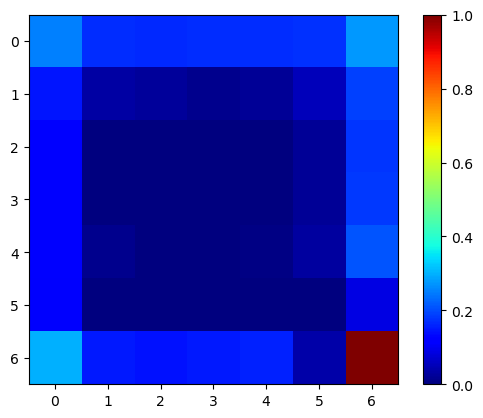

In [21]:
plt.imshow(heatmap,cmap='jet')
plt.colorbar()
plt.show()

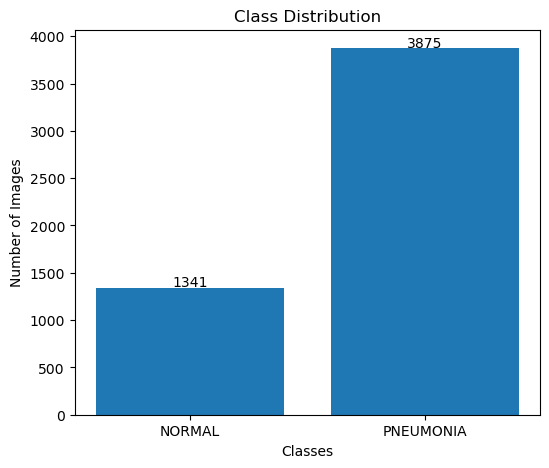

In [25]:
import os
import matplotlib.pyplot as plt

train_path ="C:/Users/admin/Downloads/pneumonia/archive/chest_xray/train"
classes = os.listdir(train_path)
counts = []

for cls in classes:
    counts.append(len(os.listdir(os.path.join(train_path, cls))))

plt.figure(figsize=(6,5))
plt.bar(classes, counts)
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")

for i, v in enumerate(counts):
    plt.text(i, v + 10, str(v), ha='center')

plt.show()

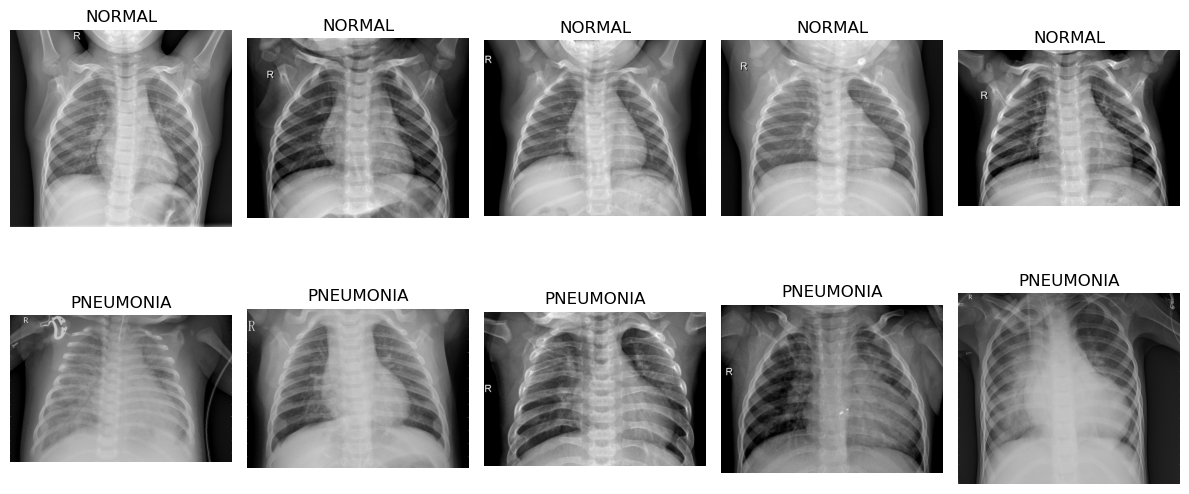

In [27]:
import matplotlib.pyplot as plt
import os
from PIL import Image

fig, axes = plt.subplots(2,5, figsize=(12,6))

classes = ["NORMAL", "PNEUMONIA"]

for row, cls in enumerate(classes):

    folder = os.path.join("C:/Users/admin/Downloads/pneumonia/archive/chest_xray/train", cls)

    images = os.listdir(folder)[:5]

    for col, img_name in enumerate(images):

        img = Image.open(os.path.join(folder, img_name))

        axes[row,col].imshow(img, cmap='gray')
        axes[row,col].set_title(cls)
        axes[row,col].axis("off")

plt.tight_layout()
plt.show()

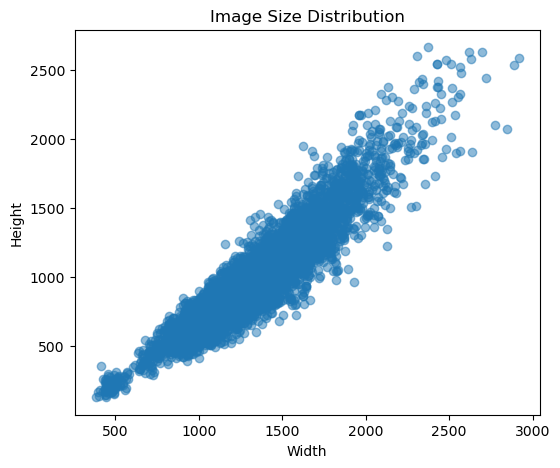

In [28]:
from PIL import Image
import os
import matplotlib.pyplot as plt

widths = []
heights = []

for cls in ["NORMAL", "PNEUMONIA"]:

    folder = os.path.join("C:/Users/admin/Downloads/pneumonia/archive/chest_xray/train", cls)

    for img in os.listdir(folder):

        image = Image.open(os.path.join(folder, img))

        w,h = image.size

        widths.append(w)
        heights.append(h)

plt.figure(figsize=(6,5))
plt.scatter(widths, heights, alpha=0.5)
plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Image Size Distribution")
plt.show()

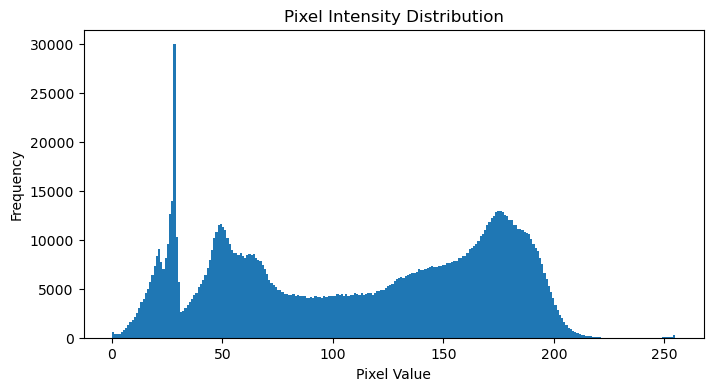

In [30]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread(
   "C:/Users/admin/Downloads/pneumonia/archive/chest_xray/train/NORMAL/NORMAL2-IM-1385-0001.jpeg",
    cv2.IMREAD_GRAYSCALE
)

plt.figure(figsize=(8,4))
plt.hist(image.ravel(), bins=256)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

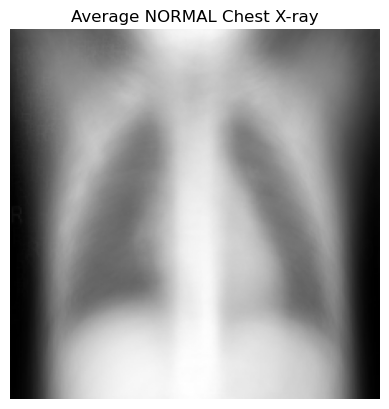

In [32]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt

images = []

folder = "C:/Users/admin/Downloads/pneumonia/archive/chest_xray/train/NORMAL"

for img in os.listdir(folder)[:200]:

    image = cv2.imread(os.path.join(folder,img),0)

    image = cv2.resize(image,(224,224))

    images.append(image)

mean_image = np.mean(images,axis=0)

plt.imshow(mean_image,cmap='gray')
plt.title("Average NORMAL Chest X-ray")
plt.axis("off")
plt.show()

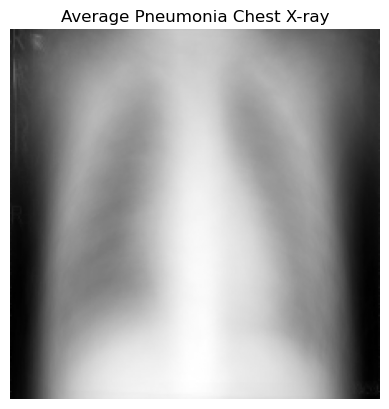

In [33]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt

images = []

folder ="C:/Users/admin/Downloads/pneumonia/archive/chest_xray/train/PNEUMONIA"

for img in os.listdir(folder)[:200]:

    image = cv2.imread(os.path.join(folder,img),0)

    image = cv2.resize(image,(224,224))

    images.append(image)

mean_image = np.mean(images,axis=0)

plt.imshow(mean_image,cmap='gray')
plt.title("Average Pneumonia Chest X-ray")
plt.axis("off")
plt.show()

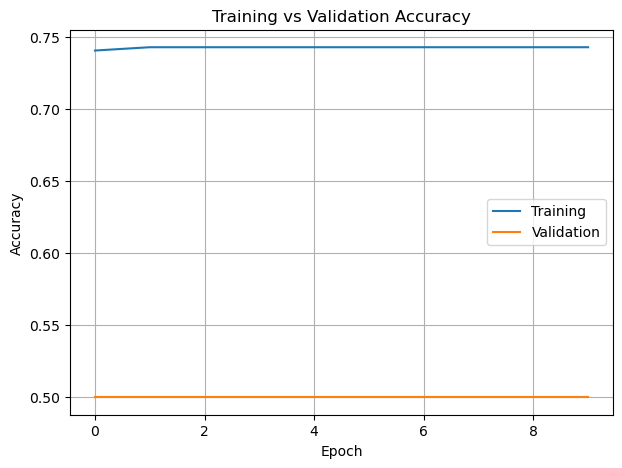

In [34]:
plt.figure(figsize=(7,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Training","Validation"])
plt.grid(True)
plt.show()

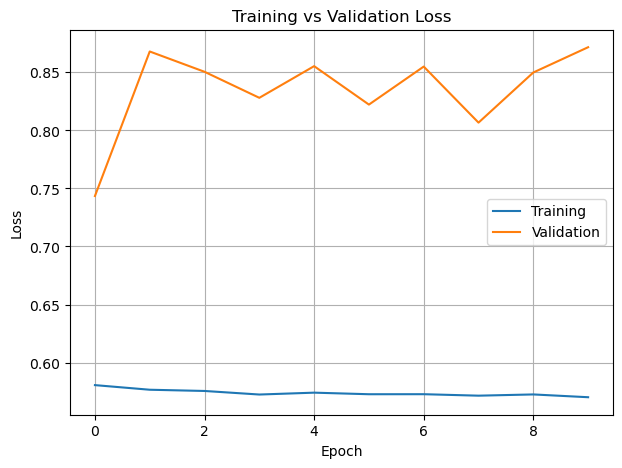

In [35]:
plt.figure(figsize=(7,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Training","Validation"])
plt.grid(True)
plt.show()

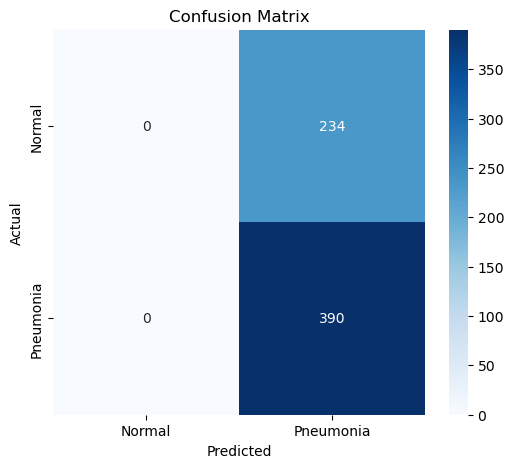

In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(test_generator.classes,pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Normal","Pneumonia"],
    yticklabels=["Normal","Pneumonia"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

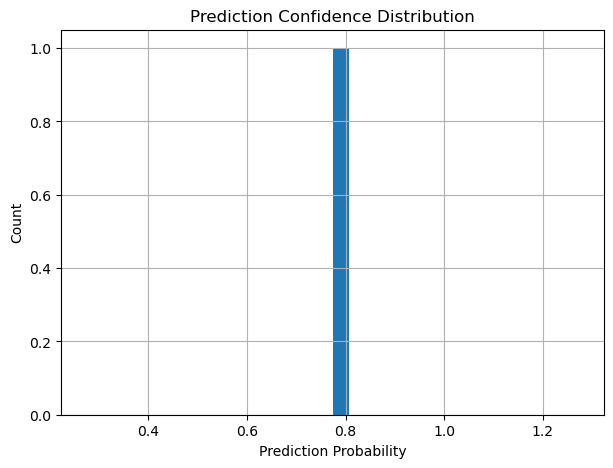

In [40]:
plt.figure(figsize=(7,5))
plt.hist(prediction, bins=30)
plt.xlabel("Prediction Probability")
plt.ylabel("Count")
plt.title("Prediction Confidence Distribution")
plt.grid(True)
plt.show()